In [ ]:
import numpy as np
import os
import requests
import tarfile
from glob import glob
from pathlib import Path
from sklearn.model_selection import train_test_split
import random
from PIL import Image
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.optimizers.schedules import LearningRateSchedule
from tensorflow.keras import backend as K
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.preprocessing import image
from keras.utils import plot_model 

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

from pydensecrf import densecrf
from pydensecrf.utils import unary_from_softmax

In [ ]:
# Définition de l'URL pour le fichier de la base de données
file_url = "http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar"

# Téléchargement et extraction du fichier
print("Téléchargement du fichier...")

response = requests.get(file_url, stream=True)
with open("VOCtrainval_11-May-2012.tar", 'wb') as file:
    for chunk in response.iter_content(chunk_size=1024):
        if chunk:
            file.write(chunk)
            
print("\nExtraction du fichier...")
with tarfile.open("VOCtrainval_11-May-2012.tar", "r") as tar:
    tar.extractall()
os.remove("VOCtrainval_11-May-2012.tar")

In [ ]:
# Création de la structure des dossiers
os.makedirs("data/images", exist_ok=True)
os.makedirs("data/annotations", exist_ok=True)

# Déplacement des fichiers téléchargés dans les dossiers appropriés
os.system("mv VOCdevkit/VOC2012/JPEGImages/* data/images/")
os.system("mv VOCdevkit/VOC2012/SegmentationClass/* data/annotations/")

In [ ]:
## Séparation des données en jeu d'entrainement, de validation et de test
# Définition des chemins d'accès aux données
image_folder = "data/images/"
annotation_folder = "data/annotations/"
# Liste des fichiers d'annotations
annotation_files = glob(os.path.join(annotation_folder, "*.png"))
# Triez la liste des fichiers d'annotations
annotation_files = sorted(annotation_files)
# Création d'une liste de paires image/annotation
file_paths = []
# Parcourir les fichiers d'annotations et créer les paires correspondantes
for annotation_path in annotation_files:
    # Extraire le nom de fichier sans extension
    annotation_name = Path(annotation_path).stem
    # Construire le chemin de l'image correspondante
    image_path = os.path.join(image_folder, f"{annotation_name}.jpg")
    # Vérifier si l'image existe
    if os.path.exists(image_path):
        # Ajouter la paire à la liste
        file_paths.append((image_path, annotation_path))
# Séparation en ensembles d'entraînement et de test (85%/15%)
train_paths, test_paths = train_test_split(file_paths, test_size=0.15, random_state=42)
# Séparation de train_paths en ensembles d'entraînement et de validation (90%/10%)
train_paths, val_paths = train_test_split(train_paths, test_size=0.15, random_state=42)

In [67]:
# vérifie les valeur des annoations
import os
import cv2
import numpy as np

def list_unique_values_in_annotations(annotation_folder):
    unique_values = set()

    # Parcourir tous les fichiers dans le dossier d'annotations
    for filename in os.listdir(annotation_folder):
        if filename.endswith(".png") or filename.endswith(".jpg"):
            # Construire le chemin complet du fichier
            file_path = os.path.join(annotation_folder, filename)

            # Charger l'image avec OpenCV
            annotation_image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

            # Extraire les valeurs uniques et les ajouter à l'ensemble
            unique_values.update(np.unique(annotation_image))

    return list(unique_values)

# Utilisation de la fonction avec votre dossier d'annotations
unique_values = list_unique_values_in_annotations(annotation_folder)

# Afficher les valeurs uniques
print("Valeurs uniques dans les annotations :", unique_values)

Valeurs uniques dans les annotations : [0, 128, 132, 14, 147, 19, 150, 33, 37, 38, 52, 57, 72, 75, 89, 220, 94, 108, 112, 113]


In [ ]:
## Affiche les dimensions d'un mask au hasard
# Sélectionner un fichier d'annotation au hasard
annotation_file = os.listdir(annotation_folder)[0]
annotation_path = os.path.join(annotation_folder, annotation_file)

# Charger l'image d'annotation
annotation = cv2.imread(annotation_path, cv2.IMREAD_UNCHANGED)  # Utiliser cv2.IMREAD_UNCHANGED pour charger les canaux alpha

# Obtenir les dimensions de l'image
dimensions = annotation.shape[:]
print(f"Dimensions de l'image d'annotation : {dimensions}")

In [3]:
print(f'Nombre de données d\'entrainement: {len(train_paths)}')
print(f'Nombre de données de validation: {len(val_paths)}')
print(f'Nombre de données de test: {len(test_paths)}')
print(train_paths[0])

Nombre de données d'entrainement: 2104
Nombre de données de validation: 372
Nombre de données de test: 437
('data/images/2007_007003.jpg', 'data/annotations\\2007_007003.png')


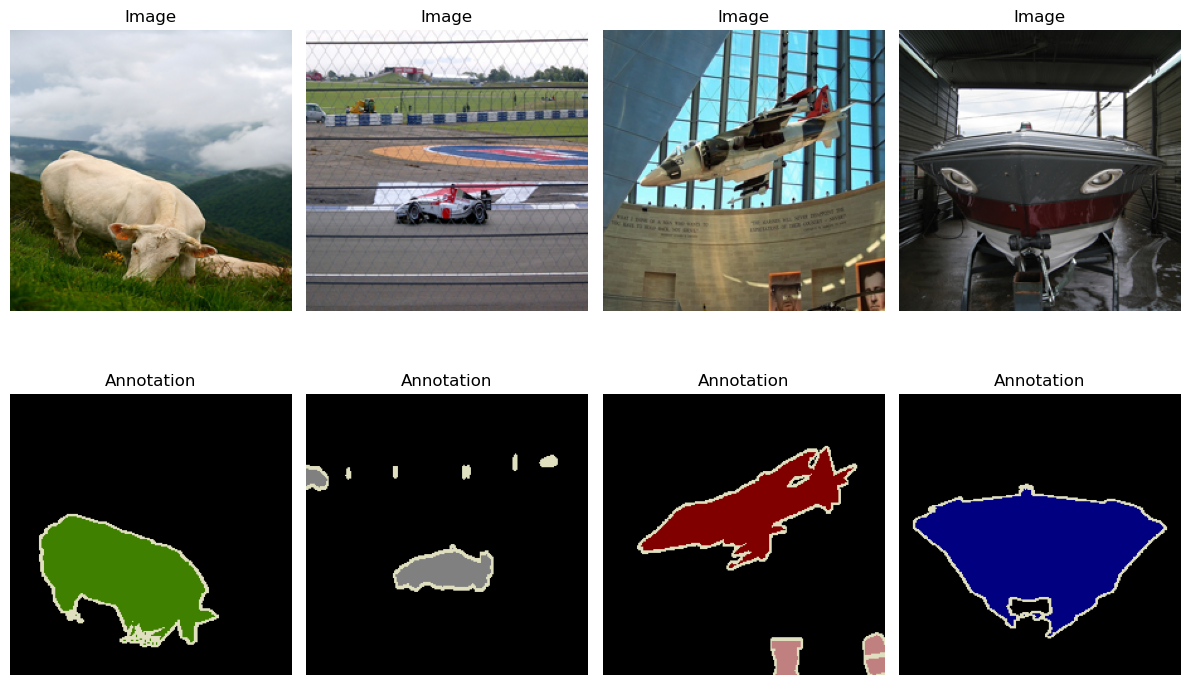

In [45]:
## Affiche 4 images avec leur masque
target_size = (224, 224)

def visualize_random_images(file_paths, num_images=4):
    # Sélectionner 4 paires d'images/annotations au hasard
    selected_paths = random.sample(file_paths, num_images)

    plt.figure(figsize=(12, 8))
    for i, (image_path, annotation_path) in enumerate(selected_paths, 1):
        # Charger l'image et l'annotation
        image = Image.open(image_path).resize(target_size)
        annotation = Image.open(annotation_path).resize(target_size)

        plt.subplot(2, num_images, i)
        plt.imshow(image)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(2, num_images, i + num_images)
        plt.imshow(annotation)       
        plt.title("Annotation")
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

# Utilisation de la fonction avec la liste des chemins de fichiers
visualize_random_images(file_paths)

In [3]:
## Pré-traitement des images : Correspondance des classes avec la colormap,
## redimensionnement, normalisation standard, augmentaiton de données

# Définition de la taille souhaitée pour les images, i.e. taille d'entrée du backbone resnet101
target_size = (224, 224)
# Correspondance classe -> colormap
voc_classes = {
    'background': 0,
    'aeroplane': 1,
    'bicycle': 2,
    'bird': 3,
    'boat': 4,
    'bottle': 5,
    'bus': 6,
    'car': 7,
    'cat': 8,
    'chair': 9,
    'cow': 10,
    'diningtable': 11,
    'dog': 12,
    'horse': 13,
    'motorbike': 14,
    'person': 15,
    'pottedplant': 16,
    'sheep': 17,
    'sofa': 18,
    'train': 19,
    'tvmonitor': 20
}
VOC_COLORMAP = [
    [0, 0, 0],
    [128, 0, 0],
    [0, 128, 0],
    [128, 128, 0],
    [0, 0, 128],
    [128, 0, 128],
    [0, 128, 128],
    [128, 128, 128],
    [64, 0, 0],
    [192, 0, 0],
    [64, 128, 0],
    [192, 128, 0],
    [64, 0, 128],
    [192, 0, 128],
    [64, 128, 128],
    [192, 128, 128],
    [0, 64, 0],
    [128, 64, 0],
    [0, 192, 0],
    [128, 192, 0],
    [0, 64, 128],
]

def load_and_preprocess_image(image_path, annotation_path):
    # Charger l'image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)

    # Charger l'image d'annotation
    annotation = tf.io.read_file(annotation_path)
    annotation = tf.image.decode_png(annotation, channels=3)

    # Convertir l'image en float32 et normaliser
    image = tf.image.convert_image_dtype(image, tf.float32) / 255.0

    # Redimensionner l'image
    image = tf.image.resize(image, target_size)

    # Redimensionner l'annotation et convertir en tenseur avec les numéros de classe
    annotation = tf.image.resize(annotation, target_size)
    annotation = tf.py_function(func=convert_to_class_tensor, inp=[annotation], Tout=tf.uint8)
    annotation.set_shape([target_size[0], target_size[1], 1])
    
    return image, annotation

def convert_to_class_tensor(annotation):
    # Fonction pour convertir l'annotation en tenseur de classe
    annotation = tf.py_function(func=map_color_to_class, inp=[annotation], Tout=tf.uint8)
    return annotation

def map_color_to_class(annotation):
    # Fonction pour mapper les couleurs aux classes
    annotation_tensor = tf.zeros_like(annotation[..., 0], dtype=tf.uint8)
    for i, color in enumerate(VOC_COLORMAP):
        mask = tf.reduce_all(tf.equal(annotation, color), axis=-1)
        annotation_tensor = tf.where(mask, i, annotation_tensor)
    return tf.expand_dims(annotation_tensor, axis=-1)

def augment_data(image, annotation):
    image = tf.image.flip_left_right(image)
    image = tf.image.flip_up_down(image)

    annotation = tf.image.flip_left_right(annotation)
    annotation = tf.image.flip_up_down(annotation)

    return image, annotation

In [4]:
##Création des Datasets pour l'entraînement et le test
train_dataset = tf.data.Dataset.from_tensor_slices(train_paths)
train_dataset = train_dataset.map(lambda x: load_and_preprocess_image(x[0], x[1]))

val_dataset = tf.data.Dataset.from_tensor_slices(val_paths)
val_dataset = val_dataset.map(lambda x: load_and_preprocess_image(x[0], x[1]))

test_dataset = tf.data.Dataset.from_tensor_slices(test_paths)
test_dataset = test_dataset.map(lambda x: load_and_preprocess_image(x[0], x[1]))

# Prendre 20% du jeu de données initial
train_dataset_subset = train_dataset.take(int(0.2 * len(train_paths)))

# Appliquer la data augmentation sur le sous-ensemble
train_dataset_augmented = train_dataset_subset.map(augment_data, num_parallel_calls=tf.data.AUTOTUNE)

# Concaténer les données augmentées avec le jeu de données d'entraînement initial
train_dataset_combined = train_dataset.concatenate(train_dataset_augmented)

In [29]:
print("Nombre d'images dans le jeu d'entrainement:", len(train_dataset))
print("Nombre d'images ajoutées par augmentation :", len(train_dataset_augmented))
print("Nombre totale d'images dans le jeu d'entrainement :", len(train_dataset_combined))
train_dataset_combined.element_spec
#test_dataset.element_spec


Nombre d'images dans le jeu d'entrainement: 2104
Nombre d'images ajoutées par augmentation : 420
Nombre totale d'images dans le jeu d'entrainement : 2524


(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(224, 224, 1), dtype=tf.uint8, name=None))

In [5]:
def compute_class_pixel_counts(dataset, class_names):
    class_counts = {}

    for image, annotation in dataset:
        # Convertir l'annotation en tableau numpy
        annotation = annotation.numpy()

        # Compter les pixels par classe
        unique_classes, class_pixel_counts = np.unique(annotation, return_counts=True)

        # Inverser le dictionnaire voc_classes
        inv_voc_classes = {v: k for k, v in class_names.items()}

        # Mettre à jour le tableau des comptes
        for cls_value, count in zip(unique_classes, class_pixel_counts):
            try:
                class_name = inv_voc_classes[cls_value]
                if class_name not in class_counts:
                    class_counts[class_name] = 0
                class_counts[class_name] += count
            except KeyError:
                print(cls_value)  # Ignorer les valeurs non définies dans le dictionnaire

    return class_counts

# Exemple d'utilisation
class_counts_train = compute_class_pixel_counts(train_dataset_combined, voc_classes)
class_counts_val = compute_class_pixel_counts(val_dataset, voc_classes)
class_counts_test = compute_class_pixel_counts(test_dataset, voc_classes)

print(class_counts_train)
print(class_counts_val)
print(class_counts_test)

{'background': 95594097, 'bus': 1994619, 'car': 1538233, 'person': 6032109, 'train': 1814482, 'dog': 2012153, 'boat': 638496, 'cow': 1248724, 'horse': 1101007, 'cat': 3103020, 'bottle': 975274, 'bicycle': 298408, 'aeroplane': 990407, 'bird': 1091778, 'chair': 1165571, 'pottedplant': 760988, 'sofa': 1758971, 'sheep': 974196, 'motorbike': 1195524, 'diningtable': 1490330, 'tvmonitor': 865837}
{'background': 13863881, 'bus': 284046, 'tvmonitor': 171576, 'person': 959946, 'sheep': 117621, 'aeroplane': 110896, 'boat': 153738, 'sofa': 233306, 'chair': 202825, 'diningtable': 207723, 'bird': 90266, 'cow': 147294, 'cat': 366466, 'dog': 452342, 'horse': 185523, 'motorbike': 235655, 'car': 377764, 'pottedplant': 16732, 'train': 350026, 'bottle': 109926, 'bicycle': 27920}
{'background': 16683597, 'person': 1001199, 'dog': 399052, 'bottle': 104655, 'diningtable': 309507, 'car': 255456, 'boat': 88381, 'cat': 469502, 'cow': 223075, 'chair': 190466, 'tvmonitor': 162339, 'sheep': 135039, 'bird': 148168,

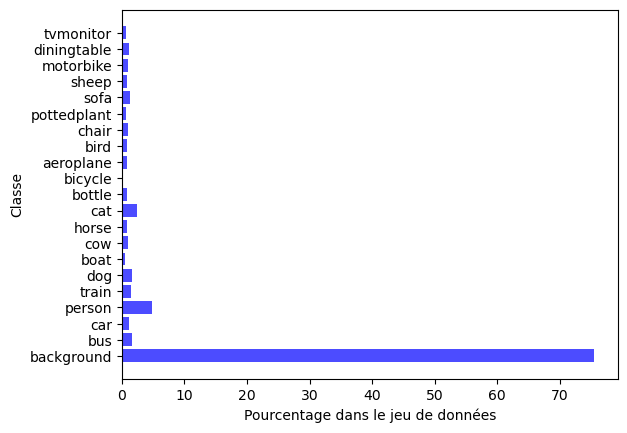

In [6]:
def compute_class_pixel_histogram(dataset, class_names):
    class_histograms = {}

    total_pixels = 0
    for image, annotation in dataset:
        # Convertir l'annotation en tableau numpy
        annotation = annotation.numpy()

        # Compter les pixels par classe
        unique_classes, class_pixel_counts = np.unique(annotation, return_counts=True)

        total_pixels += np.sum(class_pixel_counts)

        # Inverser le dictionnaire voc_classes
        inv_voc_classes = {v: k for k, v in class_names.items()}

        # Mettre à jour l'histogramme par classe
        for cls_value, count in zip(unique_classes, class_pixel_counts):
            try:
                class_name = inv_voc_classes[cls_value]
                if class_name not in class_histograms:
                    class_histograms[class_name] = 0
                class_histograms[class_name] += count
            except KeyError:
                print(cls_value)  # Ignorer les valeurs non définies dans le dictionnaire

    # Calculer les pourcentages
    for cls, count in class_histograms.items():
        class_histograms[cls] = (count / total_pixels) * 100

    return class_histograms

# Exemple d'utilisation
class_histograms = compute_class_pixel_histogram(train_dataset_combined, voc_classes)

# Tracer les histogrammes
for cls, percentage in class_histograms.items():
    plt.barh(cls, percentage, color='blue', alpha=0.7)

plt.xlabel('Pourcentage dans le jeu de données')
plt.ylabel('Classe')
#plt.title('Histogramme du pourcentage de pixels par classe')
plt.show()


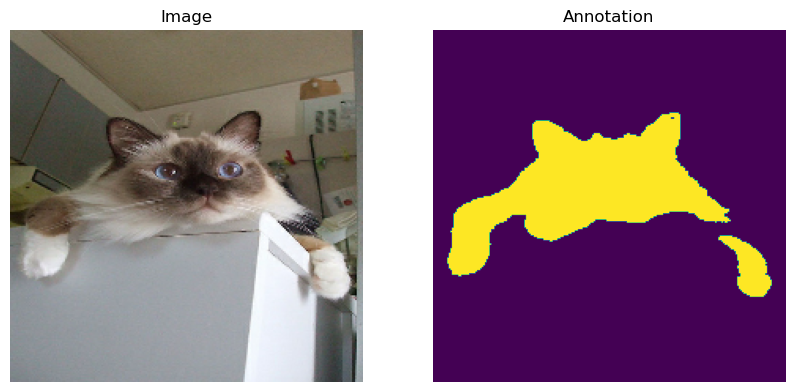

In [47]:
## Fonction pour afficher une paire image/annotation
def display_image_annotation_pair(image, annotation):
    plt.figure(figsize=(10, 5))

    # Afficher l'image
    plt.subplot(1, 2, 1)
    plt.imshow(image.numpy() * 255)
    plt.title("Image")
    plt.axis("off")

    # Afficher l'annotation
    plt.subplot(1, 2, 2)
    plt.imshow(annotation.numpy().squeeze(), cmap='gray')  # squeeze pour enlever la dimension 1
    plt.title("Annotation")
    plt.axis("off")

    plt.show()

# Mélanger l'ensemble de données d'entraînement
train_dataset_shuffled = train_dataset.shuffle(buffer_size=len(train_paths))

# Extraire une paire image/annotation du train_dataset mélangé
sample_image, sample_annotation = next(iter(train_dataset_shuffled))

# Afficher la paire image/annotation
display_image_annotation_pair(sample_image, sample_annotation)


In [2]:
## Présentation du modèle de base pour le transfert learning
resnet_model = ResNet101(weights='imagenet')

# Affichage des informations sur les couches du modèle
resnet_model.summary()

Model: "resnet101"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1_pad (ZeroPadding2D)      (None, 230, 230, 3)  0           ['input_1[0][0]']                
                                                                                                  
 conv1_conv (Conv2D)            (None, 112, 112, 64  9472        ['conv1_pad[0][0]']              
                                )                                                                 
                                                                                          

In [9]:
## Renvoi les informations sur le stride et output stride de resnet101

# Charger le modèle ResNet-101 avec les poids ImageNet
resnet_model = ResNet101(weights='imagenet', include_top=False)

# Initialiser l'output stride à 1
output_stride = 1

# Parcourir les couches et afficher les informations sur les couches de convolution
for layer in resnet_model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        # Calculer l'output stride
        output_stride *= layer.strides[0]

        # Afficher les informations sur la couche
        print(f"Layer: {layer.name}, Stride: {layer.strides[0]}, Output Stride: {output_stride}")


Layer: conv1_conv, Stride: 2, Output Stride: 2
Layer: conv2_block1_1_conv, Stride: 1, Output Stride: 2
Layer: conv2_block1_2_conv, Stride: 1, Output Stride: 2
Layer: conv2_block1_0_conv, Stride: 1, Output Stride: 2
Layer: conv2_block1_3_conv, Stride: 1, Output Stride: 2
Layer: conv2_block2_1_conv, Stride: 1, Output Stride: 2
Layer: conv2_block2_2_conv, Stride: 1, Output Stride: 2
Layer: conv2_block2_3_conv, Stride: 1, Output Stride: 2
Layer: conv2_block3_1_conv, Stride: 1, Output Stride: 2
Layer: conv2_block3_2_conv, Stride: 1, Output Stride: 2
Layer: conv2_block3_3_conv, Stride: 1, Output Stride: 2
Layer: conv3_block1_1_conv, Stride: 2, Output Stride: 4
Layer: conv3_block1_2_conv, Stride: 1, Output Stride: 4
Layer: conv3_block1_0_conv, Stride: 2, Output Stride: 8
Layer: conv3_block1_3_conv, Stride: 1, Output Stride: 8
Layer: conv3_block2_1_conv, Stride: 1, Output Stride: 8
Layer: conv3_block2_2_conv, Stride: 1, Output Stride: 8
Layer: conv3_block2_3_conv, Stride: 1, Output Stride: 8
L

In [49]:
## Calcul la réduction de dimension effectué par resnet101
# Afficher la dimension en entrée
input_shape = resnet_model.input_shape[1:3]
print("Dimension en entrée du réseau ResNet-101 :", input_shape)

# Récupérer la couche conv5_block1_1_conv (conv5_1)
conv5_1_layer = resnet_model.get_layer('conv5_block1_1_conv')

# Afficher la dimension de la sortie de la couche conv5_1
output_shape_conv5_1 = conv5_1_layer.output_shape[1:3]
print("Dimension de la sortie de conv5_1 :", output_shape_conv5_1)

# Calculer la réduction de dimension
reduction_factor = (input_shape[0] // output_shape_conv5_1[0], input_shape[1] // output_shape_conv5_1[1])
print("Réduction de dimension à la convolution conv5_block1_1_conv :", reduction_factor)

Dimension en entrée du réseau ResNet-101 : (224, 224)
Dimension de la sortie de conv5_1 : (7, 7)
Réduction de dimension à la convolution conv5_block1_1_conv : (32, 32)


In [6]:
## Création du modèle DeepLabV3

# Définir la taille d'entrée
input_shape = (224, 224, 3)  # Ajuster selon vos besoins

def Conv1x1(inputs, filters=256, dropout_rate=0.5):
        conv1x1 = layers.Conv2D(filters, (1, 1), padding='same')(inputs)
        conv1x1 = layers.BatchNormalization()(conv1x1)
        conv1x1 = layers.Activation('relu')(conv1x1)
        conv1x1 = layers.Dropout(dropout_rate)(conv1x1)
        return conv1x1

# Bloc ASPP
def aspp(inputs, filters=256, atrous_rates=[6, 12, 18], dropout_rate=0.5):
    atrous_blocks = []

    # Convolution 1x1
    conv1x1 = Conv1x1(inputs)

    # Loop through atrous rates
    for rate in atrous_rates:
        atrous_block = layers.Conv2D(filters, (3, 3), dilation_rate=rate, padding='same')(inputs)
        atrous_block = layers.BatchNormalization()(atrous_block)
        atrous_block = layers.Activation('relu')(atrous_block)
        atrous_block = layers.Dropout(dropout_rate)(atrous_block)
        atrous_blocks.append(atrous_block)

    # Concatenate atrous convolution results
    concatenated = layers.concatenate([conv1x1, atrous_blocks], axis=-1)
    
    # Global Average Pooling
    global_avg_pooling = layers.GlobalAveragePooling2D()(inputs)
    global_avg_pooling = tf.expand_dims(tf.expand_dims(global_avg_pooling, 1), 1)
    global_avg_pooling = layers.Conv2D(filters, (1, 1), padding='valid')(global_avg_pooling)
    global_avg_pooling = layers.BatchNormalization()(global_avg_pooling)
    global_avg_pooling = layers.Activation('relu')(global_avg_pooling)
    global_avg_pooling = layers.Dropout(dropout_rate)(global_avg_pooling)

    # Upsample global average pooling
    size = K.int_shape(inputs)[1:3]
    global_avg_pooling = layers.UpSampling2D(size=size, interpolation='bilinear')(global_avg_pooling)

    # Concatenate global average pooling with atrous convolution results
    concatenated = layers.concatenate([concatenated, global_avg_pooling], axis=-1)

    # 1x1 Convolution
    output = Conv1x1(concatenated)

    return output

def decodeur(inputs, backbone, input_layer, filters=256, upsampling_factor_aspp=4, dropout_rate=0.5, num_classes=21):
    # Upsampling by a factor 4
    aspp_output = layers.UpSampling2D(size=(upsampling_factor_aspp, upsampling_factor_aspp), interpolation='bilinear')(inputs)

    # Créer un modèle intermédiaire pour obtenir 'conv2_block3_out'
    intermediate_model = Model(inputs=backbone.input, outputs=backbone.get_layer('conv2_block3_out').output)

    # Récupérer les low_level_features
    low_level_features = intermediate_model(input_layer) 
    low_level_features = Conv1x1(low_level_features, filters=48)

    # Concatenate ASPP output with low level features
    concatenated = layers.concatenate([aspp_output, low_level_features], axis=-1)

    # Définir le nombre de couches de convolution
    num_conv_layers = 2

    # Utiliser une boucle for pour ajouter les couches de convolution
    for _ in range(num_conv_layers):
        concatenated = layers.Conv2D(filters, (3, 3), padding='same'))(concatenated)
        concatenated = layers.BatchNormalization()(concatenated)
        concatenated = layers.Activation('relu')(concatenated)
        concatenated = layers.Dropout(dropout_rate)(concatenated)

    concatenated = layers.UpSampling2D(size=(upsampling_factor_aspp, upsampling_factor_aspp), interpolation='bilinear')(concatenated)

    return concatenated


def deeplabv3_model(input_shape=(224, 224, 3), num_classes=21):
    # Input Layer
    input_layer = layers.Input(shape=input_shape, name='input_image')

    # Backbone (MobileNetV2 in this example)
    backbone = tf.keras.applications.ResNet101(input_shape=input_shape, include_top=False, weights='imagenet', pooling='avg')

    # Exclure les couches dense et de pooling global
    output_layer = backbone.get_layer('conv5_block3_out').output

    # Créer un nouveau modèle avec la sortie désirée
    resnet_model = Model(inputs=backbone.input, outputs=output_layer)

    # Fine-tuning des couches du backbone
    for layer in resnet_model.layers:
        layer.trainable = True
    
    multi_grid = (1, 2, 1)    
    # Nom des couches de convolution à remplacer dans conv5
    conv_layers_to_replace = ['conv5_block1_0_conv', 'conv5_block1_1_conv',
                            'conv5_block1_2_conv', 'conv5_block1_3_conv',
                            'conv5_block2_1_conv', 'conv5_block2_2_conv',
                            'conv5_block2_3_conv', 'conv5_block3_1_conv',
                            'conv5_block3_2_conv', 'conv5_block3_3_conv']

    # Modifier directement les couches de convolution dans conv5
    for layer in resnet_model.layers:
        if layer.name in conv_layers_to_replace and isinstance(layer, Conv2D):
            # Calculer le numéro du block en fonction du nom de la couche
            block_number = int(layer.name.split('_')[2][-1])  # Extrait le numéro du block de la couche
            # Configurer les taux de dilatation
            layer.strides = (1, 1)
            layer.dilation_rate = (2 * multi_grid[block_number - 1], 2 * multi_grid[block_number - 1])
    
            
    resnet_model_output = resnet_model(input_layer)
    
    # ASPP Block
    aspp_output = aspp(resnet_model_output, dropout_rate=0.8)

    # Decoder
    decoder_output = decodeur(aspp_output, backbone=backbone, input_layer=input_layer, dropout_rate=0.8)

    # Predictions
    predictions = layers.Conv2D(num_classes, (1, 1), padding='same', activation='softmax')(decoder_output)

    # Create model
    model = Model(inputs=input_layer, outputs=predictions, name='deeplabv3')

    return model

# Instantiate the model
model = deeplabv3_model()

plot_model(model, to_file='final_model.png')

# Afficher le résumé du modèle modifié
model.summary()

aspp_output before upsampling (None, 14, 14, 256)
aspp_output (None, 56, 56, 256)
Model: "deeplabv3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_image (InputLayer)       [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 model (Functional)             (None, 7, 7, 2048)   42658176    ['input_image[0][0]']            
                                                                                                  
 conv2d (Conv2D)                (None, 14, 14, 256)  4718848     ['model[0][0]']                  
                                                                                                  
 conv2d_

In [41]:
## Paramètres personnalisés pour l'entraînement
# Paramètres
batch_size = 16
epochs = 5

# Définition d'un taux d'apprentissage 'poly'
class PolyDecay(LearningRateSchedule):
    def __init__(self, initial_learning_rate, max_epochs, power=0.9):
        self.initial_learning_rate = initial_learning_rate
        self.max_epochs = max_epochs
        self.power = power

    def __call__(self, step):
        #return self.initial_learning_rate * (1 - step / float(self.max_epochs))**self.power
        return self.initial_learning_rate * (1 - step / self.max_epochs)**self.power

# Utilisation de la classe PolyDecay
initial_lr = 0.007  # Taux d'apprentissage initial
poly_decay = PolyDecay(initial_learning_rate=initial_lr, max_epochs=epochs)

# Création de l'optimiseur avec le taux d'apprentissage initial
optimizer = tf.keras.optimizers.Adam(learning_rate=poly_decay)


# Fonction de perte customisée
def custom_loss(y_true, y_pred):
    # Créer un masque pour exclure la classe du background (classe 0)
    mask = tf.math.not_equal(y_true, 0)

    # Calculez la perte de cross-entropy pour chaque position spatiale, en tenant compte du masque
    pixel_losses = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred, from_logits=False)
    masked_pixel_losses = tf.boolean_mask(pixel_losses, mask)

    # Ajoutez une régularisation L2
    l2_loss = 0.01 * tf.reduce_sum([tf.nn.l2_loss(w) for w in model.trainable_variables])

    # Sommez les pertes masquées et la régularisation pour obtenir la perte totale
    total_loss = tf.reduce_sum(masked_pixel_losses) + l2_loss

    return total_loss


# Compilation du modèle
model.compile(optimizer=optimizer,
              loss=custom_loss,
              metrics=['accuracy'])

# Définition de l'arrêt anticipé (early stopping)
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [42]:
## Entraîner le modèle avec l'ensemble d'entraînement
#model.fit(train_dataset_combined.batch(batch_size), epochs=epochs)

# Entraînement du modèle avec régularisation et early stopping
model.fit(train_dataset_combined.batch(batch_size), epochs=epochs, validation_data=val_dataset.batch(batch_size), callbacks=[early_stopping])

Epoch 1/5
158/158 [==============================] - 1024s 6s/step - loss: nan - accuracy: 0.7394 - val_loss: nan - val_accuracy: 0.7428
Epoch 2/5
158/158 [==============================] - 983s 6s/step - loss: nan - accuracy: 0.7548 - val_loss: nan - val_accuracy: 0.7428
Epoch 3/5
158/158 [==============================] - 1019s 6s/step - loss: nan - accuracy: 0.7548 - val_loss: nan - val_accuracy: 0.7428


In [20]:
model.save_weights("DeepLabV3_weights .h5")

In [ ]:
model.load_weights('DeepLabV3_weights.h5')

In [33]:
def calculate_iou(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    iou_score = np.sum(intersection) / np.sum(union)
    return iou_score

In [ ]:
# Évaluer le modèle sur l'ensemble de test
evaluation_result = model.evaluate(test_dataset.batch(batch_size))
test_accuracy = evaluation_result[1]
print(f"Test Accuracy: {test_accuracy}")

# Calculer mIoU
miou_values = []

for images, ground_truth in test_dataset.batch(batch_size):
    # Faire des prédictions avec le modèle
    predictions = model.predict(images)

    # Convertir les prédictions en classes (indices)
    predicted_classes = np.argmax(predictions, axis=-1)

    # Calculer IoU pour chaque paire
    iou_values = [calculate_iou(gt, pred) for gt, pred in zip(ground_truth.numpy(), predicted_classes)]

    # Ajouter la moyenne de IoU pour cet ensemble à la liste
    miou_values.append(np.mean(iou_values))

# Calculer la moyenne des mIoU sur tous les ensembles de test
mean_miou = np.mean(miou_values)
print(f"Mean IoU (mIoU): {mean_miou}")

test_image_array (1, 224, 224, 3)
test_annotation (224, 224, 1)
1/1 [==============================] - 0s 150ms/step
predictions (1, 224, 224, 21)
predicted_class (224, 224)
predicted_class [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Classe 0: Occurrence 50176
IoU 0.0


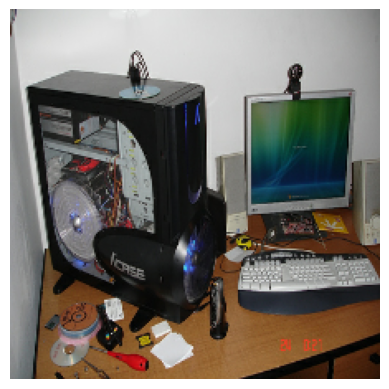

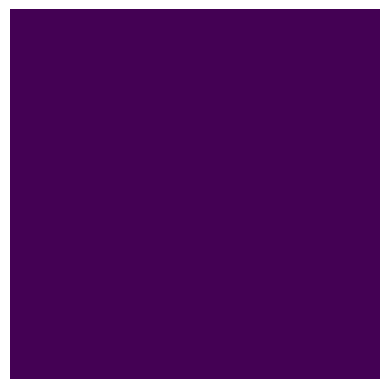

In [44]:
## Faire une prédiction et l'afficher
# Charger une image de test au hasard parmi les chemins disponibles
random_test_path = random.choice(train_paths)

# Charger l'image de test en utilisant la fonction de prétraitement
test_image, test_annotation = load_and_preprocess_image(random_test_path[0], random_test_path[1])

# Ajouter une dimension pour correspondre à la forme attendue par le modèle
test_image_array = np.expand_dims(test_image, axis=0)
print('test_image_array', test_image_array.shape)
print('test_annotation', test_annotation.shape)

# Faire des prédictions
predictions = model.predict(test_image_array)
predicted_class = np.argmax(predictions, axis=-1)[0]
print('predictions', predictions.shape)
print('predicted_class', predicted_class.shape)
print('predicted_class', predicted_class)

# Compter les valeurs uniques
unique_values, counts = np.unique(predicted_class, return_counts=True)

# Afficher les valeurs uniques et leurs occurrences
for value, count in zip(unique_values, counts):
    print(f"Classe {value}: Occurrence {count}")

IoU = calculate_iou(test_annotation, predicted_class)
print('IoU',IoU)

# Afficher l'image de test
plt.imshow(test_image_array[0]*255)
plt.axis('off')
plt.show()

# Tracer la carte de segmentation
#segmentation_map = predictions[0][:, :, predicted_class]
#plt.imshow(segmentation_map, cmap='viridis')
plt.imshow(predicted_class)
plt.axis('off')
plt.show()


In [ ]:
## Définition de la fonction de CRF indiqué dans l'article
def apply_crf(image, predictions, num_classes=21, 
              w1=10.0, w2=5.0, sigma_alpha=1.0, sigma_beta=50.0, sigma_gamma=3.0):
    # Préparer l'image pour le CRF
    image = image.astype(np.uint8)
    predictions = predictions.argmax(axis=-1).astype(np.uint32)

    # Configurer le modèle CRF
    d = densecrf.DenseCRF2D(image.shape[1], image.shape[0], num_classes)
    
    # Convertir les prédictions du modèle en probabilités
    unary = unary_from_softmax(predictions)
    d.setUnaryEnergy(unary)

    # Obtenir les coordonnées des pixels dans l'image
    h, w = image.shape[:2]
    coords = np.mgrid[0:w, 0:h].reshape((2, -1)).astype(np.int32)

    # Calculer les différences de positions et d'intensités de couleur
    pos_diff = np.linalg.norm(coords[:, :, None] - coords[:, None, :], axis=0)
    color_diff = np.linalg.norm(image.reshape((-1, 1, 3)) - image.reshape((1, -1, 3)), axis=-1)

    # Calculer le terme μ(xi, xj)
    pairwise_energy = np.ones((num_classes, num_classes), dtype=np.float32)
    np.fill_diagonal(pairwise_energy, 0.0)

    # Calculer les termes exp dans l'équation (3)
    exp_term1 = np.exp(-pos_diff / (2.0 * sigma_alpha**2))
    exp_term2 = np.exp(-color_diff / (2.0 * sigma_beta**2))

    # Calculer l'énergie pairwise θij(xi, xj)
    pairwise_energy *= (w1 * exp_term1 + w2 * exp_term2)

    # Définir l'énergie pairwise dans le modèle CRF
    d.addPairwiseEnergy(pairwise_energy, compat=3)

    # Effectuer l'inférence
    Q = d.inference(5)

    # Obtenir les résultats
    result = np.argmax(Q, axis=0).reshape(image.shape[:2])

    return result

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold

# Définir les hyperparamètres à optimiser et leurs valeurs possibles
param_grid = {
    'w1': [5.0, 10.0, 15.0],
    'sigma_alpha': [0.5, 1.0, 2.0],
    'sigma_beta': [20.0, 50.0, 100.0]
}

def calculate_iou(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    iou_score = np.sum(intersection) / np.sum(union)
    return iou_score

# Définir la fonction d'évaluation (score) basée sur la métrique que vous souhaitez optimiser
def crf_evaluation(params, image, predictions, ground_truth):
    result = apply_crf(image, predictions, w1=params['w1'], sigma_alpha=params['sigma_alpha'], sigma_beta=params['sigma_beta'])
    # Calculez la métrique que vous souhaitez optimiser (par exemple, IoU)
    iou = calculate_iou(result, ground_truth)  # Assurez-vous d'avoir cette fonction définie
    return iou

# Utiliser GridSearchCV avec une validation croisée k-fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # Choisissez le nombre de plis (fold)
grid_search = GridSearchCV(estimator=None, param_grid=param_grid, cv=kf, scoring=crf_evaluation, verbose=1)

# Boucle sur votre ensemble d'entraînement pour entraîner et évaluer le modèle
for train_index, val_index in kf.split(train_paths):
    train_set = [train_paths[i] for i in train_index]
    val_set = [train_paths[i] for i in val_index]

    # Chargement et prétraitement des ensembles d'entraînement et de validation
    train_data = [load_and_preprocess_image(x[0], x[1]) for x in train_set]
    val_data = [load_and_preprocess_image(x[0], x[1]) for x in val_set]

    train_images, train_ground_truth = zip(*train_data)
    val_images, val_ground_truth = zip(*val_data)

    train_images = np.array(train_images)
    train_ground_truth = np.array(train_ground_truth)

    val_images = np.array(val_images)
    val_ground_truth = np.array(val_ground_truth)

    # Entraînez votre modèle ici avec l'ensemble d'entraînement
    model.fit(train_images, train_ground_truth, epochs=epochs)

    # Appliquer la recherche par grille avec la validation croisée
    grid_search.fit(val_images, val_ground_truth)

# Obtenez les meilleurs paramètres trouvés
best_params = grid_search.best_params_
print("Best Hyperparameters:", best_params)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, jaccard_score
from pydensecrf import densecrf
from pydensecrf.utils import unary_from_labels

# Liste pour stocker les vérités terrain (annotations), les prédictions initiales et les prédictions post-traitées
ground_truth_list = []
initial_predictions_list = []
post_processed_predictions_list = []

# Boucle sur l'ensemble de test pour obtenir les vérités terrain, les prédictions initiales et les prédictions post-traitées
for image, ground_truth in test_dataset.batch(batch_size):
    # Faire des prédictions avec le modèle
    current_predictions = model.predict(image)

    # Appliquer le post-traitement avec CRF
    post_processed_predictions = []

    for i in range(len(current_predictions)):
        post_processed_result = apply_crf(image[i].numpy(), current_predictions[i])
        post_processed_predictions.append(post_processed_result)

    # Ajouter les vérités terrain, les prédictions initiales et les prédictions post-traitées à la liste
    ground_truth_list.append(ground_truth.numpy())
    initial_predictions_list.append(current_predictions.argmax(axis=-1))
    post_processed_predictions_list.append(post_processed_predictions)

# Concaténer les listes pour obtenir des tableaux numpy
ground_truth = np.concatenate(ground_truth_list)
initial_predictions = np.concatenate(initial_predictions_list)
post_processed_predictions = np.concatenate(post_processed_predictions_list)

# Flatten les matrices pour calculer les métriques
ground_truth_flat = ground_truth.flatten()
initial_predictions_flat = initial_predictions.flatten()
post_processed_predictions_flat = post_processed_predictions.flatten()

# Calcul des métriques pour les prédictions initiales
accuracy_initial = accuracy_score(ground_truth_flat, initial_predictions_flat)
precision_initial = precision_score(ground_truth_flat, initial_predictions_flat, average='weighted')
recall_initial = recall_score(ground_truth_flat, initial_predictions_flat, average='weighted')
f1_initial = f1_score(ground_truth_flat, initial_predictions_flat, average='weighted')
iou_initial = jaccard_score(ground_truth_flat, initial_predictions_flat, average='weighted')

# Calcul des métriques pour les prédictions post-traitées
accuracy_post_processed = accuracy_score(ground_truth_flat, post_processed_predictions_flat)
precision_post_processed = precision_score(ground_truth_flat, post_processed_predictions_flat, average='weighted')
recall_post_processed = recall_score(ground_truth_flat, post_processed_predictions_flat, average='weighted')
f1_post_processed = f1_score(ground_truth_flat, post_processed_predictions_flat, average='weighted')
iou_post_processed = jaccard_score(ground_truth_flat, post_processed_predictions_flat, average='weighted')

print("Metrics for Initial Predictions:")
print(f"Accuracy: {accuracy_initial}")
print(f"Precision: {precision_initial}")
print(f"Recall: {recall_initial}")
print(f"F1 Score: {f1_initial}")
print(f"IoU (Jaccard Score): {iou_initial}")

print("\nMetrics for Post-Processed Predictions:")
print(f"Accuracy: {accuracy_post_processed}")
print(f"Precision: {precision_post_processed}")
print(f"Recall: {recall_post_processed}")
print(f"F1 Score: {f1_post_processed}")
print(f"IoU (Jaccard Score): {iou_post_processed}")


In [ ]:
# Visualisation d'une image avec la prédiction initiale, la prédiction post-traitée et la vérité terrain
index = 0  # Choisissez un indice d'image
plt.figure(figsize=(18, 6))

plt.subplot(1, 4, 1)
plt.imshow(image[index])
plt.title("Image")

plt.subplot(1, 4, 2)
plt.imshow(initial_predictions[index], cmap='tab20b', vmin=0, vmax=20)  # Ajuster vmin et vmax en fonction du nombre de classes
plt.title("Initial Prediction")

plt.subplot(1, 4, 3)
plt.imshow(post_processed_predictions[index], cmap='tab20b', vmin=0, vmax=20)  # Ajuster vmin et vmax en fonction du nombre de classes
plt.title("Post-Processed Prediction")

plt.subplot(1, 4, 4)
plt.imshow(ground_truth[index], cmap='tab20b', vmin=0, vmax=20)  # Ajuster vmin et vmax en fonction du nombre de classes
plt.title("Ground Truth")

plt.show()

In [ ]:
import random

# Définir une fonction pour l'affichage d'une image avec sa prédiction post-traitée
def display_image_with_overlay(image, post_processed_result, idx):
    overlay_image = np.zeros_like(image)
    overlay_image[..., 0] = post_processed_result / np.max(post_processed_result)  # Utiliser le canal rouge
    overlay_image[..., 1] = image[..., 1]  # Garder le canal vert de l'image d'origine
    overlay_image[..., 2] = image[..., 2]  # Garder le canal bleu de l'image d'origine

    plt.subplot(3, 2, idx * 2 - 1)
    plt.imshow(image)
    plt.title(f"Image {idx}")

    plt.subplot(3, 2, idx * 2)
    plt.imshow(overlay_image)
    plt.title(f"Post-Processed Prediction {idx}")

# Sélectionner 3 indices au hasard dans le jeu de test
random_indices = random.sample(range(len(test_paths)), 3)

# Préparer une figure pour l'affichage des résultats
plt.figure(figsize=(18, 6))

# Boucle pour l'affichage des résultats
for idx, selected_index in enumerate(random_indices, 1):
    # Charger et prétraiter l'image
    image, _ = load_and_preprocess_image(test_paths[selected_index][0], test_paths[selected_index][1])

    # Faire des prédictions avec le modèle
    current_predictions = model.predict(image[tf.newaxis, ...])

    # Appliquer le post-traitement avec CRF
    post_processed_result = apply_crf(image.numpy(), current_predictions[0])

    # Appeler la fonction pour l'affichage
    display_image_with_overlay(image, post_processed_result, idx)

plt.tight_layout()
plt.show()